## Importing libraries

In [1]:
# importing libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Directions to run code:
1. Install Python 3.10 or later.
2. Install dependencies (pandas, numpy, matplotlib and seaborn).
3. Place the dataset file in the `data/` folder called `hotel_bookings.csv`..
4. Run the script.
5. The cleaned dataset and graphs will be saved as `cleaned_hotel_bookings.csv`.

In [2]:
# loading data
df = pd.read_csv('hotel_bookings.csv')
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,1,29,2016,February,6,5,6,14,1,...,No Deposit,9.0,NaN,0,Transient,70.91,0,0,Canceled,2016-01-15
1,Resort Hotel,0,312,2017,March,10,5,2,5,2,...,No Deposit,298.0,NaN,0,Transient-Party,56.00,0,0,Check-Out,2017-03-12
2,Resort Hotel,0,19,2016,February,9,27,0,1,2,...,No Deposit,5.0,NaN,0,Transient,0.00,0,0,Check-Out,2016-02-28


## Step 2: Data Inspection

### 1) Initially inspecting dataset

In [3]:
df.shape

(119987, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119987 entries, 0 to 119986
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119987 non-null  object 
 1   is_canceled                     119987 non-null  int64  
 2   lead_time                       119987 non-null  int64  
 3   arrival_date_year               119987 non-null  int64  
 4   arrival_date_month              119987 non-null  object 
 5   arrival_date_week_number        119987 non-null  int64  
 6   arrival_date_day_of_month       119987 non-null  int64  
 7   stays_in_weekend_nights         119987 non-null  int64  
 8   stays_in_week_nights            119987 non-null  int64  
 9   adults                          119987 non-null  int64  
 10  children                        119805 non-null  float64
 11  babies                          119987 non-null  int64  
 12  meal            

### 2) Analysing Missing Values

In [5]:
# Calculating the percentage and absolute count of missing values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_values = pd.DataFrame({
    'Number of Missing Values': missing_counts,
    'Missing (in %)': missing_percent
}).sort_values(by='Number of Missing Values', ascending=False)

print(missing_values.head(10))

                      Number of Missing Values  Missing (in %)
company                                 113162       94.311884
agent                                    16541       13.785660
country                                    628        0.523390
children                                   182        0.151683
distribution_channel                       164        0.136681
customer_type                              154        0.128347
meal                                       138        0.115012
market_segment                             129        0.107512
booking_changes                              0        0.000000
deposit_type                                 0        0.000000


### 3) Analyzing Unique Values (Categorical)

In [6]:
# Checking for inconsistencies in key categorical columns
categorical_cols = ['hotel', 'market_segment', 'customer_type', 'meal', 'distribution_channel']
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())




Unique values in hotel:
['City Hotel' 'Resort Hotel' 'ResortHotel' 'CityHotel']

Unique values in market_segment:
['Online TA' 'Groups' 'Complementary' 'Direct' nan 'Offline TA/TO'
 'Corporate' 'Aviation' 'Corporate ' 'groups' 'Direc' 'offline ta/to'
 'COMPLEMENTARY' 'Undefined ' 'Undefined']

Unique values in customer_type:
['Transient' 'Transient-Party' 'Contract' 'Group' nan 'Transient '
 'Transient-Party ' 'contract' 'GROUP']

Unique values in meal:
['BB' 'HB' 'SC' 'FB' 'Undefined' nan 'HB ' 'bb' 'Undefined ' 'FB ' 'SC ']

Unique values in distribution_channel:
['TA/TO' 'Direct' 'Corporate' 'TA/TO ' 'GDS' 'Direct ' nan 'Corporate '
 'Undefined' 'gds']


## Step 3: Data Preprocessing & Cleaning

### 1) Basic Cleaning: Striping of whitespaces and handle casing

In [7]:
# Checking for inconsistencies in key categorical columns
categorical_cols = ['hotel', 'market_segment', 'customer_type', 'meal', 'distribution_channel']
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

# General Cleaning: Stripping spaces and handling casing
cols_to_fix = ['market_segment', 'customer_type', 'meal', 'distribution_channel', 'reservation_status']

for col in cols_to_fix:
    df[col] = df[col].str.strip() # Remove trailing/leading spaces
    
    if col in ['meal', 'reservation_status', 'distribution_channel']:
        df[col] = df[col].str.upper()
    else:
        df[col] = df[col].str.title()

# Specific Value Mapping: Fixing typing errors and 'Undefined' values

df['market_segment'] = df['market_segment'].str.strip().str.lower()

segment_map = {
    'online ta': 'Online TA',
    'online ta/to': 'Online TA',
    'offline ta/to': 'Offline TA/TO',
    'offline ta': 'Offline TA/TO',
    'direct': 'Direct',
    'direc' : 'Direct',
    'undefined': 'Online TA',
    'corporate': 'Corporate',
    'groups': 'Groups',
    'group': 'Groups',
    'complementary': 'Complementary',
    'aviation': 'Aviation'
}

hotel_map = {
    'City Hotel': 'City Hotel',
    'Resort Hotel': 'Resort Hotel',
    'ResortHotel': 'Resort Hotel',
    'CityHotel': 'City Hotel'
}

distribution_channel_map = {
    'TA/TO':     'TA/TO',
    'DIRECT':    'Direct',   
    'CORPORATE': 'Corporate', 
    'GDS':       'GDS',
    'UNDEFINED': 'TA/TO',    
    'NAN':       'TA/TO'     
}




df['hotel'] = df['hotel'].replace(hotel_map).fillna('City Hotel')
df['market_segment'] = df['market_segment'].map(segment_map)
df['meal'] = df['meal'].replace('UNDEFINED', 'SC')
df['distribution_channel'] = df['distribution_channel'].replace(distribution_channel_map).fillna('TA/TO')




Unique values in hotel:
['City Hotel' 'Resort Hotel' 'ResortHotel' 'CityHotel']

Unique values in market_segment:
['Online TA' 'Groups' 'Complementary' 'Direct' nan 'Offline TA/TO'
 'Corporate' 'Aviation' 'Corporate ' 'groups' 'Direc' 'offline ta/to'
 'COMPLEMENTARY' 'Undefined ' 'Undefined']

Unique values in customer_type:
['Transient' 'Transient-Party' 'Contract' 'Group' nan 'Transient '
 'Transient-Party ' 'contract' 'GROUP']

Unique values in meal:
['BB' 'HB' 'SC' 'FB' 'Undefined' nan 'HB ' 'bb' 'Undefined ' 'FB ' 'SC ']

Unique values in distribution_channel:
['TA/TO' 'Direct' 'Corporate' 'TA/TO ' 'GDS' 'Direct ' nan 'Corporate '
 'Undefined' 'gds']


### 2) Handling missing values

In [8]:
fill_values = {
    'children': 0,
    'country': 'Unknown',
    'agent': 0,
    'market_segment': 'Online TA',
    'customer_type': 'Transient',
    'meal': 'BB'
}

df.fillna(value=fill_values, inplace=True)

### 3) Dropping columns With high percentage of missing data

In [9]:
df.drop(columns=['company'], inplace=True, errors='ignore')

### 4) Converting Data Types

In [10]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], format='mixed', errors='coerce')

### 5) Handling outliers

In [11]:
# Identifying rows with 0 adults, children, and babies
no_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"Number of bookings with zero total guests: {len(no_guests)}")

# Removing rows with no guests
df = df.drop(no_guests.index)

# Inspecting extreme outliers in 'adults'
print("\nExtreme outliers in adults:")
print(df['adults'].value_counts().sort_index(ascending=False).head(5))

# Removing extreme outliers (guest with more 10 members)
# These represent less than 0.01% of the data and are all canceled bookings.
df = df[df['adults'] <= 10]

Number of bookings with zero total guests: 180

Extreme outliers in adults:
adults
55    1
50    1
40    1
27    2
26    5
Name: count, dtype: int64


In [12]:
# Identifying rows with negative ADR
negative_adr_count = len(df[df['adr'] < 0])
print(f"Number of bookings with negative ADR: {negative_adr_count}")

# Removing or resetting negative ADR values
# Since there's only one record, we can drop it as it's an outlier.
df = df[df['adr'] >= 0]

# Handling extreme ADR outliers
# From initial inspection, there is a value of 5400, which is over 50x the average.
print("\nTop 5 highest ADR values:")
print(df['adr'].sort_values(ascending=False).head(5))

# We cap the ADR at 5000 and removed the 5400 outlier to ensure visuals aren't distorted.
df = df[df['adr'] < 5000]

print("\nFinancial cleaning (ADR) complete.")

Number of bookings with negative ADR: 1

Top 5 highest ADR values:
115673    5400.00
534       1586.74
4850      1480.57
119191    1436.43
42106     1421.92
Name: adr, dtype: float64

Financial cleaning (ADR) complete.


## Step 4: Exploratory Data Analysis (EDA)

### 1) Cancellation rate by hotel type (City Hotel vs Resort Hotel)

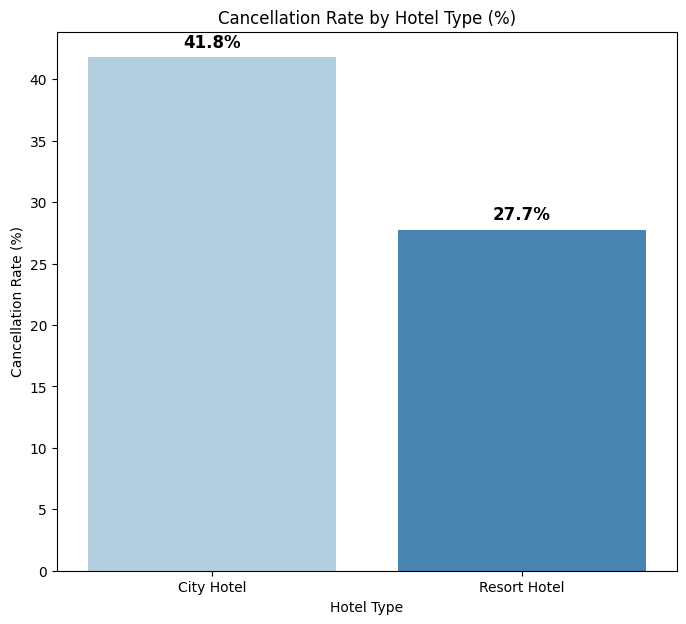

In [13]:
hotel_cancel = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize=(8, 7))
ax = sns.barplot(x=hotel_cancel.index, y=hotel_cancel.values, palette='Blues',hue=hotel_cancel.index, legend=False)
plt.title('Cancellation Rate by Hotel Type (%)')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Hotel Type')
# Add percentage labels on top of each bar
for bar, val in zip(ax.patches, hotel_cancel.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        bar.get_height() + 0.5,              # y position: just above bar
        f'{val:.1f}%',                        # label: e.g. "41.8%"
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )


plt.savefig('cancellation_rate_by_hotel.png')

### 2) Impact of lead time on cancellations

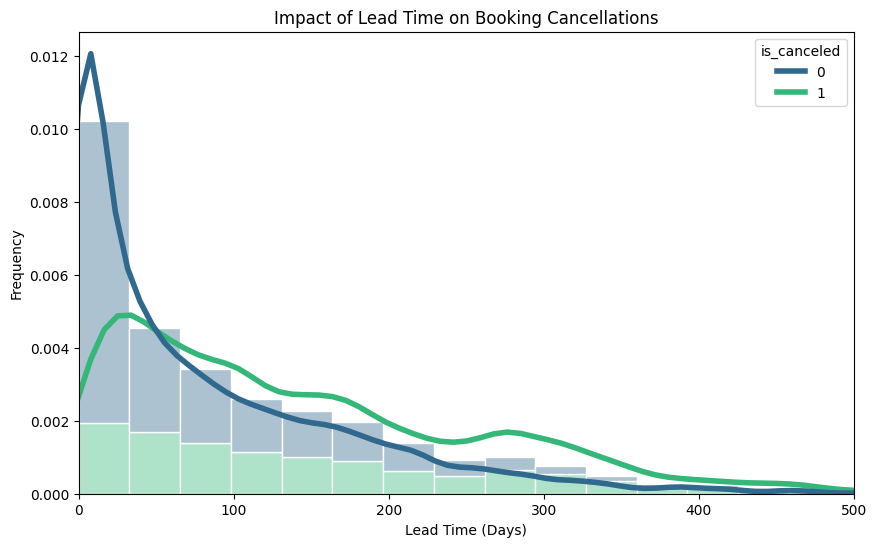

In [14]:
plt.figure(figsize=(10, 6))
# sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=50, 
#              palette='viridis', multiple='stack', alpha=0.4, edgecolor='white',state = 'density')
sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=50,
             palette='viridis', multiple='stack', alpha=0.4,
             edgecolor='white', stat='density') 

# 2. Enhanced Trend Lines (KDE) - Plotted independently with thicker linewidth
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', 
            palette='viridis', linewidth=4, common_norm=False)

# 3. Limiting X-axis to 500 for detail (covers 99%+ of data)
plt.xlim(0, 500)
plt.title('Impact of Lead Time on Booking Cancellations')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.savefig('lead_time_impact.png')

### 3) Total Special Requests vs. Cancellation Status

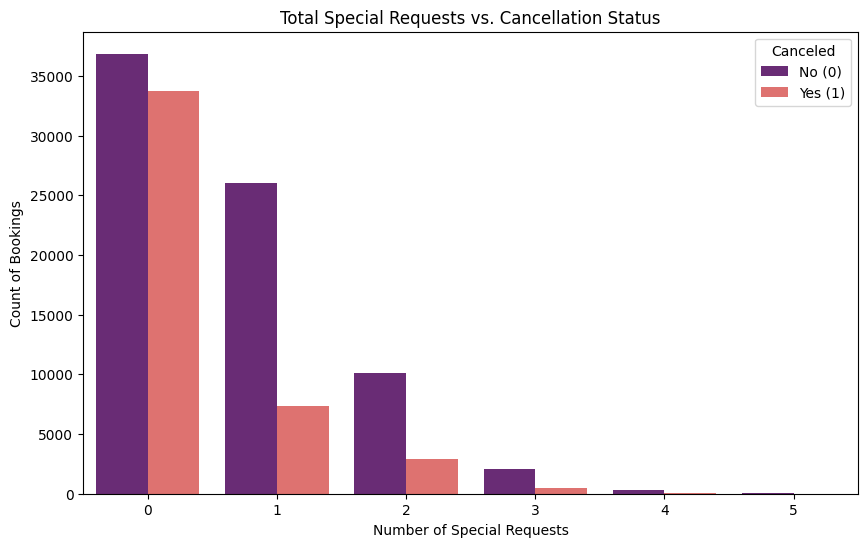

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='total_of_special_requests', hue='is_canceled', palette='magma')

plt.title('Total Special Requests vs. Cancellation Status')
plt.xlabel('Number of Special Requests')
plt.ylabel('Count of Bookings')
plt.legend(title='Canceled', labels=['No (0)', 'Yes (1)'])

plt.savefig('special_requests_cancellation.png')

### 4) Deposit type vs cancellation behavior

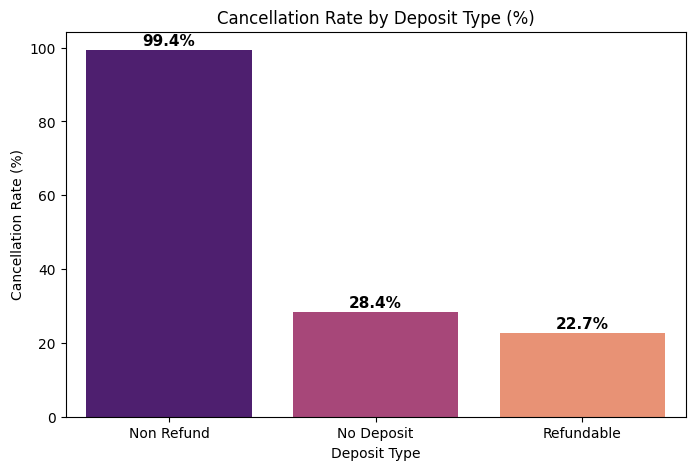

In [16]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100
deposit_cancel = deposit_cancel.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=deposit_cancel.index, y=deposit_cancel.values,
                 hue=deposit_cancel.index, palette='magma', legend=False)
plt.title('Cancellation Rate by Deposit Type (%)')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Deposit Type')
#Add percentage labels on top of each bar
for bar, val in zip(ax.patches, deposit_cancel.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
plt.savefig('deposit_type_cancellation.png')

### 5) Correlation Analysis

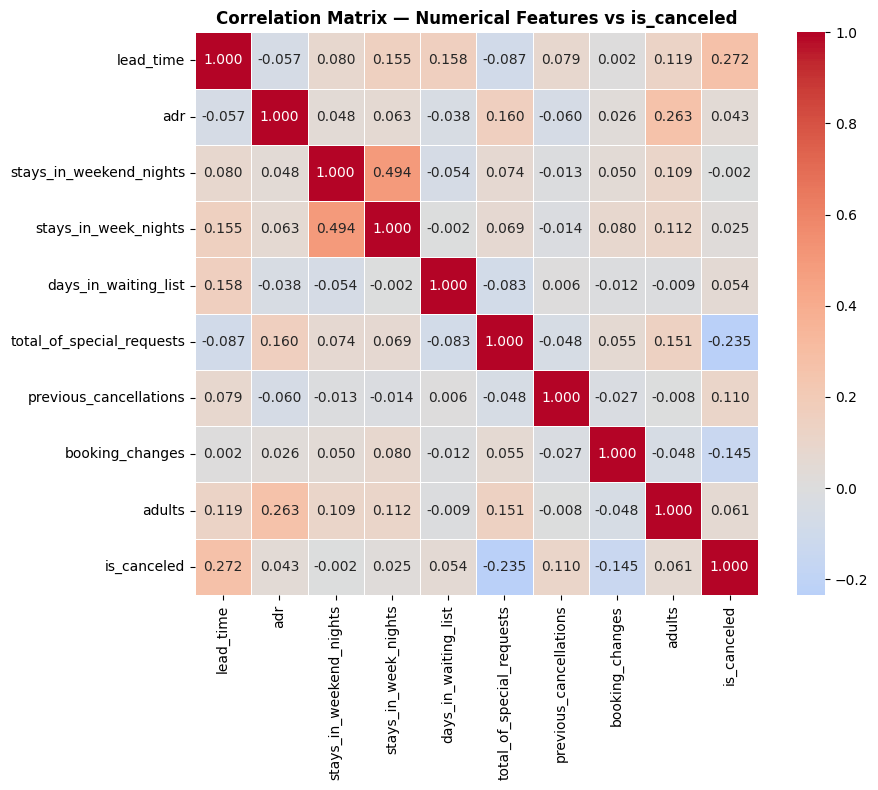

=== Correlations with is_canceled ===
lead_time                    0.2716
previous_cancellations       0.1102
adults                       0.0611
days_in_waiting_list         0.0544
adr                          0.0429
stays_in_week_nights         0.0255
stays_in_weekend_nights     -0.0015
booking_changes             -0.1449
total_of_special_requests   -0.2348


In [17]:
# 4.5 Correlation Analysis 
num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'days_in_waiting_list', 'total_of_special_requests',
            'previous_cancellations', 'booking_changes', 'adults', 'is_canceled']

corr_matrix = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features vs is_canceled', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Correlation with target only
corr_target = corr_matrix['is_canceled'].drop('is_canceled').sort_values(ascending=False)
print('=== Correlations with is_canceled ===')
print(corr_target.round(4).to_string())

### 6) Monthly or seasonal cancellation trends

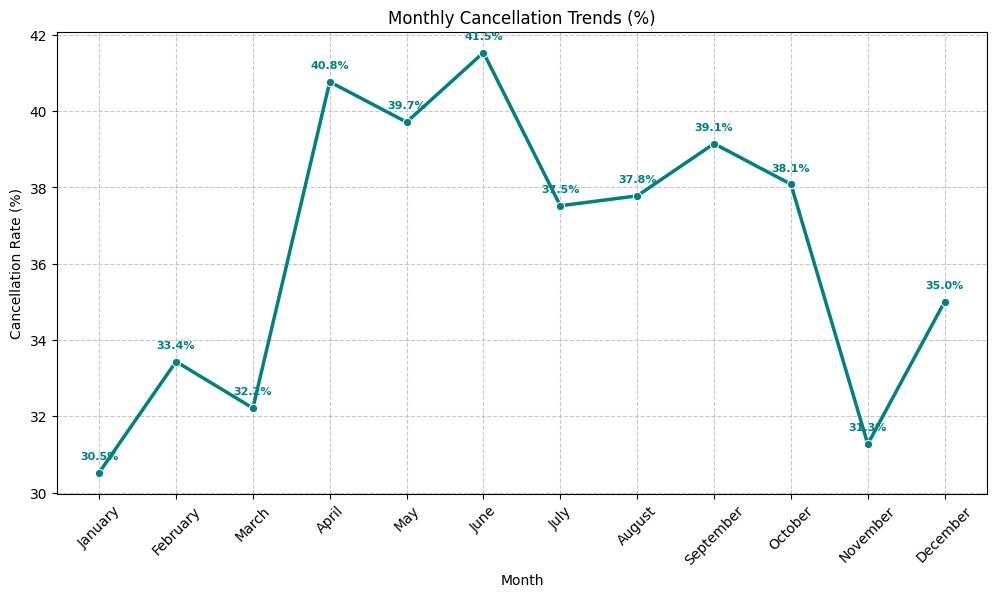

In [18]:
# Sorting months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

monthly_cancel = df.groupby('arrival_date_month',observed=True)['is_canceled'].mean() * 100

plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values,
             marker='o', linewidth=2.5, color='teal', ax=ax)
# Add percentage labels above each data point
for i, (month, val) in enumerate(zip(monthly_cancel.index, monthly_cancel.values)):
    ax.text(i, val + 0.3, f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='teal')
plt.title('Monthly Cancellation Trends (%)')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('monthly_cancellation_trends.png')

### 7) Previous Cancellations and Market Segment Influence

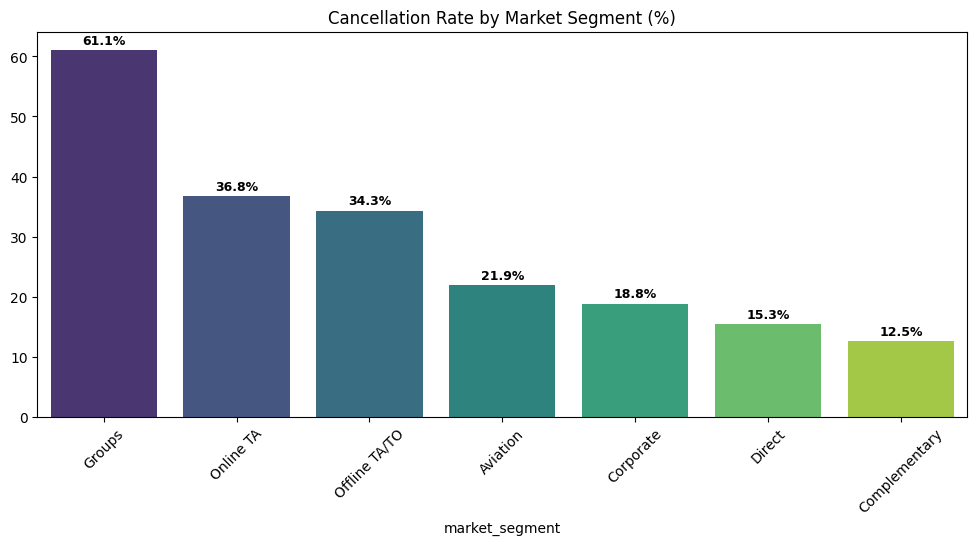

In [19]:
# Market Segment influence
plt.figure(figsize=(12, 5))
market_cancel = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False) * 100
ax = sns.barplot(x=market_cancel.index, y=market_cancel.values, hue=market_cancel.index, palette='viridis',legend=False)
plt.title('Cancellation Rate by Market Segment (%)')
plt.xticks(rotation=45)
# Add percentage labels on top of each bar
for bar, val in zip(ax.patches, market_cancel.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
plt.savefig('market_segment_cancellation.png')

## Step 5: Final output and saving data

In [20]:
df.to_csv('cleaned_hotel_bookings.csv', index=False)

print(f"Final dataset cleaned. Shape: {df.shape}")
print("All analysis graphs and the cleaned CSV file have been saved.")


Final dataset cleaned. Shape: (119793, 31)
All analysis graphs and the cleaned CSV file have been saved.
